In [3]:
!pip3 install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you 

In [1]:
!pip3 install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554972 sha256=ad938707c764011c1bc5a708c88ddedcd2d3a865384b7239836f02d1ca9ce8ee
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
import pandas as pd
import numpy as np

def run_ingestion(ratings_path, titles_path):
    print("Ingestion & Optimization...")

    df_ratings = pd.read_csv(ratings_path, header=None, names=['UserID', 'Rating', 'Date'])
    movie_id_mask = df_ratings['Rating'].isnull()
    df_ratings.loc[movie_id_mask, 'MovieID'] = df_ratings.loc[movie_id_mask, 'UserID'].str.replace(':', '')
    df_ratings['MovieID'] = df_ratings['MovieID'].ffill().astype(np.int32)
    df_ratings = df_ratings[~movie_id_mask].reset_index(drop=True)

    df_ratings['UserID'] = df_ratings['UserID'].astype(np.int32)
    df_ratings['Rating'] = df_ratings['Rating'].astype(np.int8)
    df_ratings = df_ratings.drop('Date', axis=1)

    df_titles = pd.read_csv(titles_path, encoding='iso-8859-1', header=None,
                            names=['MovieID', 'Year', 'Title'], on_bad_lines='skip')
    df_titles['Year'] = df_titles['Year'].fillna(0).astype(np.int16)

    merged_df = pd.merge(df_ratings, df_titles, on='MovieID', how='inner')
    merged_df.to_parquet('merged_movie_data.parquet', index=False)
    print(f"'merged_movie_data.parquet' created with {len(merged_df):,} rows.\n")

run_ingestion('/content/combined_data_1.txt', '/content/movie_titles.csv')

Ingestion & Optimization...
'merged_movie_data.parquet' created with 23,807,405 rows.



In [ ]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time
from google.colab import userdata

TMDB_KEY = userdata.get('TMDB_KEY')
OMDB_KEY = userdata.get('OMDB_KEY')
GENRE_MAP = {28: 'Action', 12: 'Adventure', 16: 'Animation', 35: 'Comedy', 80: 'Crime', 99: 'Documentary', 18: 'Drama', 10751: 'Family', 14: 'Fantasy', 36: 'History', 27: 'Horror', 10402: 'Music', 9648: 'Mystery', 10749: 'Romance', 878: 'Science Fiction', 10770: 'TV Movie', 53: 'Thriller', 10752: 'War', 37: 'Western'}

def get_genres_from_api(title, year):
    """The 'Smart' Logic: Checks Movie (Year Drift) -> TV -> OMDB"""
    years_to_try = [year, year - 1, year + 1, None] if year != 0 else [None]

    for y in years_to_try:

        try:
            url = f"https://api.themoviedb.org/3/search/movie?api_key={TMDB_KEY}&query={title}&region=GB"
            if y: url += f"&primary_release_year={y}"
            res = requests.get(url, timeout=5).json()
            if res.get('results'):
                ids = res['results'][0].get('genre_ids', [])
                return "|".join([GENRE_MAP.get(i) for i in ids if i in GENRE_MAP])
        except: pass

        try:
            url = f"https://api.themoviedb.org/3/search/tv?api_key={TMDB_KEY}&query={title}"
            if y: url += f"&first_air_date_year={y}"
            res = requests.get(url, timeout=5).json()
            if res.get('results'):
                ids = res['results'][0].get('genre_ids', [])
                return "|".join([GENRE_MAP.get(i) for i in ids if i in GENRE_MAP])
        except: pass

    try:
        url = f"http://www.omdbapi.com/?apikey={OMDB_KEY}&t={title}&y={year}"
        res = requests.get(url, timeout=5).json()
        if res.get('Response') == 'True':
            return res.get('Genre').replace(', ', '|')
    except: pass

    return "Unknown"

def run_scraper():
    print("API Enrichment...")
    titles_df = pd.read_csv('/content/movie_titles.csv', encoding='iso-8859-1', header=None,
                            names=['MovieID', 'Year', 'Title'], on_bad_lines='skip')
    titles_df['Year'] = titles_df['Year'].fillna(0).astype(int)

    results = []
    with ThreadPoolExecutor(max_workers=20) as executor:
        futures = {executor.submit(get_genres_from_api, r['Title'], r['Year']): r['MovieID'] for _, r in titles_df.iterrows()}
        for f in tqdm(as_completed(futures), total=len(titles_df), desc="Fetching Genres"):
            results.append({'MovieID': futures[f], 'Genres': f.result()})

    genres_df = pd.DataFrame(results)
    genres_df.to_csv('movie_genres_mapped.csv', index=False)
    print("'movie_genres_mapped.csv' created.\n")

run_scraper()

API Enrichment...


Fetching Genres: 100%|██████████| 17434/17434 [08:15<00:00, 35.20it/s]

'movie_genres_mapped.csv' created.



In [ ]:
def run_consolidation():
    print("Consolidation...")
    df_main = pd.read_parquet('merged_movie_data.parquet')
    df_genres = pd.read_csv('movie_genres_mapped.csv')

    df_genres['Genres'] = df_genres['Genres'].fillna('Unknown').astype(str)
    df_genres['Genres'] = df_genres['Genres'].replace(['Not Found', 'Error', ''], 'Unknown')

    master_df = pd.merge(df_main, df_genres[['MovieID', 'Genres']], on='MovieID', how='left')
    master_df['Genres'] = master_df['Genres'].fillna('Unknown').str.replace(',', '|')

    master_df.to_parquet('final_master_dataset.parquet', index=False)
    print("'final_master_dataset.parquet' created.\n")

run_consolidation()

Consolidation...
'final_master_dataset.parquet' created.



In [ ]:
def run_final_polish():
    print("Final Polish...")
    df = pd.read_parquet('final_master_dataset.parquet')

    manual_fixes = {
        "Isle of Man TT 2004 Review": "Documentary|Sports",
        "Paula Abdul's Get Up & Dance": "Music|Special Interest",
        "Dinosaur Planet": "Documentary|Animation",
        "The Rise and Fall of ECW": "Documentary|Sports"
    }

    for title, genre in manual_fixes.items():
        df.loc[df['Title'] == title, 'Genres'] = genre

    df_cleaned = df[df['Genres'] != 'Unknown'].copy()

    df_cleaned.to_parquet('final_master_dataset_cleaned.parquet', index=False, compression='snappy')
    print(f"Final dataset size: {len(df_cleaned):,} rows.")
    print(df_cleaned.head())
run_final_polish()

Final Polish...
Final dataset size: 21,869,525 rows.
    UserID  Rating  MovieID  Year            Title                 Genres
0  1488844       3        1  2003  Dinosaur Planet  Documentary|Animation
1   822109       5        1  2003  Dinosaur Planet  Documentary|Animation
2   885013       4        1  2003  Dinosaur Planet  Documentary|Animation
3    30878       4        1  2003  Dinosaur Planet  Documentary|Animation
4   823519       3        1  2003  Dinosaur Planet  Documentary|Animation


Aggregating movie statistics...
Exploding genres on movie-level data...
genre_popularity.png


/tmp/ipykernel_16869/160380235.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_quality.values, y=genre_quality.index, palette='magma')


genre_quality.png

--- NEW STATS (ACCURATE) ---
Total Ratings Processed: 21,869,525
Highest Rated Genre: Sports (3.74)
Most Rated Genre: Drama (10,422,257)


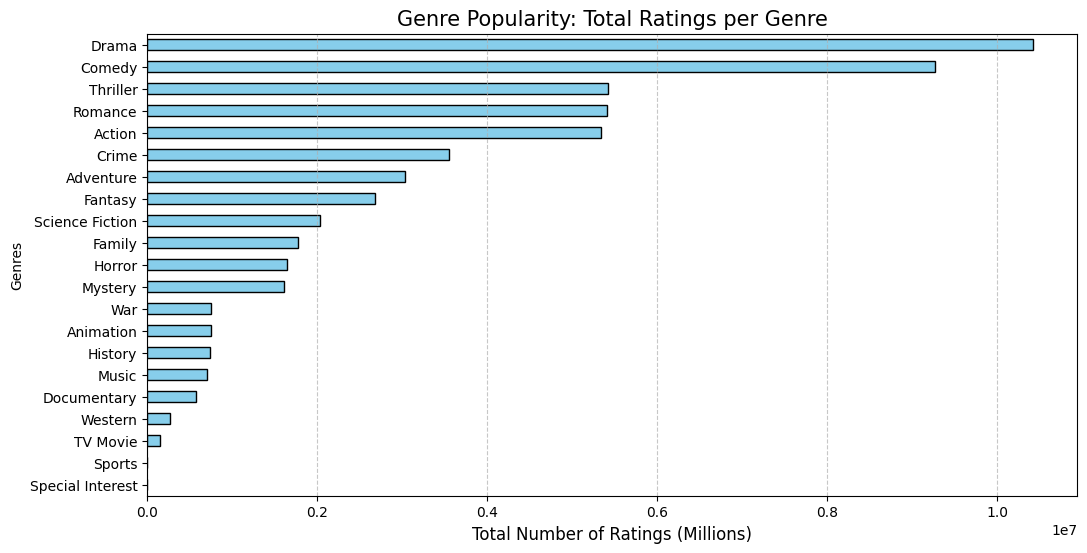

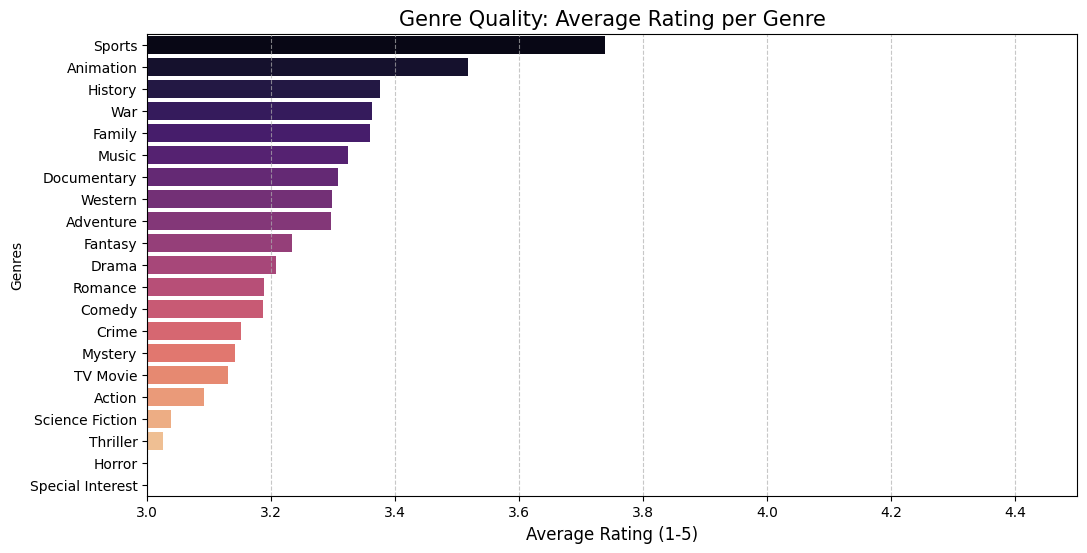

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_eda_low_ram(file_path):
    df = pd.read_parquet(file_path)

    print("Aggregating movie statistics...")
    movie_stats = df.groupby('MovieID').agg({
        'Rating': ['count', 'mean'],
        'Genres': 'first',
        'Title': 'first'
    }).reset_index()

    movie_stats.columns = ['MovieID', 'Rating_Count', 'Avg_Rating', 'Genres', 'Title']

    print("Exploding genres on movie-level data...")
    movie_stats['Genres'] = movie_stats['Genres'].str.split('|')
    df_exploded = movie_stats.explode('Genres')

    plt.figure(figsize=(12, 6))
    genre_popularity = df_exploded.groupby('Genres')['Rating_Count'].sum().sort_values(ascending=True)
    genre_popularity.plot(kind='barh', color='skyblue', edgecolor='black')

    plt.title('Genre Popularity: Total Ratings per Genre', fontsize=15)
    plt.xlabel('Total Number of Ratings (Millions)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig('genre_popularity.png', bbox_inches='tight')
    print("genre_popularity.png")

    plt.figure(figsize=(12, 6))
    genre_quality = df_exploded.groupby('Genres')['Avg_Rating'].mean().sort_values(ascending=False)
    sns.barplot(x=genre_quality.values, y=genre_quality.index, palette='magma')

    plt.title('Genre Quality: Average Rating per Genre', fontsize=15)
    plt.xlabel('Average Rating (1-5)', fontsize=12)
    plt.xlim(3, 4.5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.savefig('genre_quality.png', bbox_inches='tight')
    print("genre_quality.png")

    print("\n--- NEW STATS (ACCURATE) ---")
    print(f"Total Ratings Processed: {movie_stats['Rating_Count'].sum():,}")
    print(f"Highest Rated Genre: {genre_quality.index[0]} ({genre_quality.values[0]:.2f})")
    print(f"Most Rated Genre: {genre_popularity.index[-1]} ({genre_popularity.values[-1]:,})")

run_eda_low_ram('final_master_dataset_cleaned.parquet')

In [ ]:
import pandas as pd

# Load the file
df = pd.read_parquet('final_master_dataset_cleaned.parquet')

# Check length and unique counts
print(f"Total Rows: {len(df):,}")
print(f"Unique Movies: {df['MovieID'].nunique():,}")
print(f"Unique Users: {df['UserID'].nunique():,}")

# Check first few rows to see if genres are present
print("\n--- Data Preview ---")
print(df.head())

Total Rows: 21,869,525
Unique Movies: 3,557
Unique Users: 469,251

--- Data Preview ---
    UserID  Rating  MovieID  Year            Title                 Genres
0  1488844       3        1  2003  Dinosaur Planet  Documentary|Animation
1   822109       5        1  2003  Dinosaur Planet  Documentary|Animation
2   885013       4        1  2003  Dinosaur Planet  Documentary|Animation
3    30878       4        1  2003  Dinosaur Planet  Documentary|Animation
4   823519       3        1  2003  Dinosaur Planet  Documentary|Animation


In [2]:
import pandas as pd
from surprise import SVD, Reader, Dataset
import joblib
import gc

print("Loading Data...")
df = pd.read_parquet('/content/final_master_dataset_cleaned.parquet', columns=['UserID', 'MovieID', 'Rating'])
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df, reader)
del df
gc.collect()

print("Building Trainset...")
trainset = data.build_full_trainset()

del data
gc.collect()

# 3. TRAIN MODEL
print("Training SVD")
model = SVD(n_factors=50, n_epochs=20, random_state=42)
model.fit(trainset)

# 4. PREPARE FOR SAVE
print("Cleaning memory before save...")
del trainset
gc.collect()

# 5. SAVE
print("Writing .pkl file...")
joblib.dump(model, 'netflix_model_final.pkl', compress=1)
print("Model saved without crashing.")

Loading Data...
Building Trainset...
Training SVD
Cleaning memory before save...
Writing .pkl file...
Model saved without crashing.
Created metadata with 4414 movies from File 1.


In [7]:
import pandas as pd
import os
import gc

def create_complete_metadata(titles_path, genres_path):
    print("Creating metadata...")

    df_titles = pd.read_csv(titles_path,
                            encoding='iso-8859-1',
                            header=None,
                            names=['MovieID', 'Year', 'Title'],
                            on_bad_lines='skip')

    df_titles['MovieID'] = df_titles['MovieID'].astype(int)

    if os.path.exists(genres_path):
        print("Merging with scraped genres...")
        df_genres = pd.read_csv(genres_path)
        df_genres['MovieID'] = df_genres['MovieID'].astype(int)

        df_meta = pd.merge(df_titles, df_genres[['MovieID', 'Genres']], on='MovieID', how='left')
    else:
        print("⚠️ Warning: Genres file not found. Titles only will be used.")
        df_meta = df_titles.copy()
        df_meta['Genres'] = 'Unknown'

    df_meta['Genres'] = df_meta['Genres'].fillna('Unknown')

    df_meta.to_parquet('full_movie_metadata.parquet', index=False)
    print(f"Success! 'full_movie_metadata.parquet' created with {len(df_meta)} movies.")

    del df_titles, df_meta
    gc.collect()

create_complete_metadata('/content/movie_titles.csv', '/content/movie_genres_mapped.csv')

Creating metadata...
Merging with scraped genres...
Success! 'full_movie_metadata.parquet' created with 17434 movies.


In [1]:
import pandas as pd
import joblib
import gc
import os

gc.collect()
model_path = 'netflix_model_final.pkl'

if os.path.exists(model_path):
    print("Loading Model...")
    model = joblib.load(model_path)
    print("Model Loaded.")
else:
    print("Model file not found.")

meta_path = 'full_movie_metadata.parquet'
if os.path.exists(meta_path):
    df_meta = pd.read_parquet(meta_path, columns=['MovieID', 'Title', 'Genres'])

    movie_lookup = df_meta.set_index('MovieID').to_dict('index')
    del df_meta
    gc.collect()
    print(f"Metadata Loaded: {len(movie_lookup)} movies.")

Loading Model...
Model Loaded.
Metadata Loaded: 17434 movies.


In [10]:
def get_recommendations(user_id, top_n=10):
    """
    Generates recommendations for the full 17,770 catalog.
    Uses 'movie_lookup' as defined in your previous cell.
    """
    all_movie_ids = list(movie_lookup.keys())

    u_id = int(user_id)

    print(f"Scanning all {len(all_movie_ids)} movies for User {u_id}...")

    preds = [model.predict(u_id, mid) for mid in all_movie_ids]

    preds.sort(key=lambda x: x.est, reverse=True)

    top_preds = preds[:top_n]

    final_list = []
    for p in top_preds:
        info = movie_lookup.get(p.iid, {'Title': 'Unknown', 'Genres': 'Unknown'})
        final_list.append({
            'MovieID': p.iid,
            'Title': info.get('Title'),
            'Genres': info.get('Genres'),
            'Score': round(p.est, 2)
        })

    return pd.DataFrame(final_list)

try:
    results = get_recommendations(user_id=1331154)
    display(results)
except NameError as e:
    print(f"Error: {e}. Make sure you ran the Loading code successfully first.")

Scanning all 17434 movies for User 1331154...


,MovieID,Title,Genres,Score
0,2803,Pride and Prejudice,Documentary,4.85
1,3456,Lost: Season 1,Animation,4.81
2,167,The Chorus,Drama|Comedy|Music,4.71
3,2743,The Pianist,Drama|War,4.67
4,3033,Ghost in the Shell: Stand Alone Complex: 2nd Gig,Animation|Science Fiction,4.65
5,3679,Commanding Heights: The Battle for the World E...,Documentary,4.64
6,1941,The Life of Birds,Documentary,4.61
7,2299,Shadow of the Thin Man,Comedy|Crime|Mystery,4.60
8,2754,The Life of Mammals,Documentary,4.60
9,2899,Riding Giants,Documentary,4.58
